# 时间序列预测：工作量预测

**目标**：用过去 24 个月（2024-06 ~ 2026-05）的每月工作量数据，预测未来六个月（2026-06 ~ 2026-11）的工作量。

**方法**：对比 5 种预测方法，选择最优模型进行预测。

**验证**：以最后 2 个月为验证集，计算 MAE、RMSE、MAPE。

> 预测 6 个月比预测 2 个月更具挑战性：
> - 预测误差会随时间累积，越远的月份越不可靠
> - 模型假设（如线性趋势）在更长的时间跨度上更可能失效

---
## 1. 导入库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from scipy.fft import fft, fftfreq, ifft

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('库导入成功')

库导入成功


---
## 2. 加载数据 & 可视化

In [2]:
df = pd.read_csv('../data/workload.csv', parse_dates=['date'])
df = df.set_index('date').asfreq('MS')
print('数据预览：')
display(df)
print('统计描述：')
display(df.describe().round(1))

数据预览：


,workload
date,
2024-06-01,132.8
2024-07-01,140.9
2024-08-01,175.7
2024-09-01,211.8
2024-10-01,203.1
2024-11-01,211.5
2024-12-01,236.3
2025-01-01,212.5
2025-02-01,177.0


统计描述：


,workload
count,24.0
mean,192.3
std,35.1
min,132.8
25%,167.0
50%,196.0
75%,216.0
max,255.7


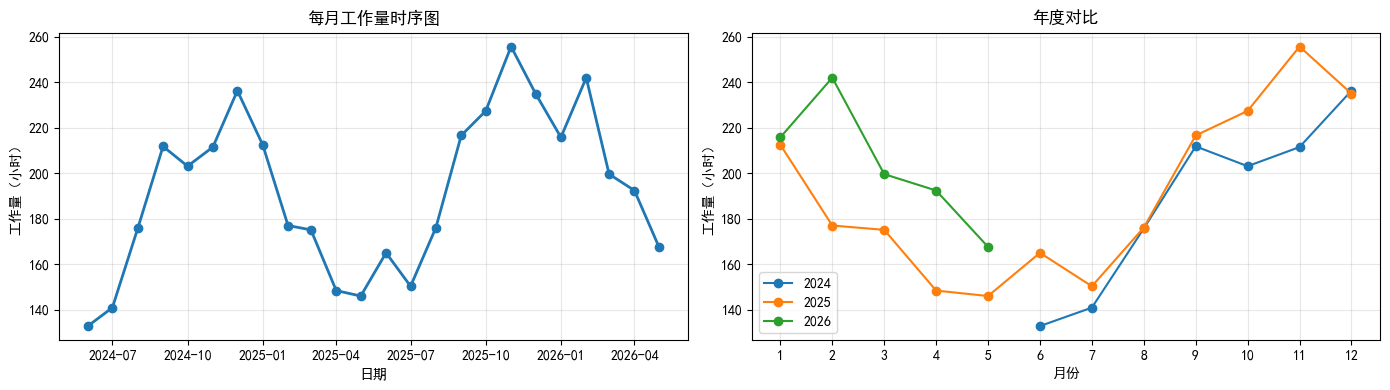

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 时间序列图
axes[0].plot(df.index, df['workload'], marker='o', linestyle='-', linewidth=2)
axes[0].set_title('每月工作量时序图')
axes[0].set_xlabel('日期')
axes[0].set_ylabel('工作量（小时）')
axes[0].grid(True, alpha=0.3)

# 年度对比
for year in [2024, 2025, 2026]:
    yr_data = df[df.index.year == year]
    if not yr_data.empty:
        axes[1].plot(yr_data.index.month, yr_data['workload'], marker='o', label=str(year))
axes[1].set_title('年度对比')
axes[1].set_xlabel('月份')
axes[1].set_ylabel('工作量（小时）')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. 傅里叶变换分析：提取周期与趋势

在正式建模之前，先用 **傅里叶变换（FFT）** 分析数据的频率成分。

### 基本原理

傅里叶变换的核心思想是：**任何时间序列都可以分解为一系列不同频率的正弦波/余弦波的叠加**。

$$
y(t) = \sum_{k} A_k \cdot \sin(2\pi f_k t + \phi_k)
$$

其中 $A_k$ 是振幅（该频率成分的强度），$f_k$ 是频率，$\phi_k$ 是相位。

通过分析各频率的**功率（振幅平方）**，我们可以识别出数据中的主要周期：
- **低频 → 趋势**（长期缓慢变化）
- **中频 → 季节性**（12 个月周期）
- **高频 → 噪声**（随机波动）

然后通过 **频率滤波** 将三种成分分离。

In [4]:
y = df['workload'].values
n = len(y)

# 计算 FFT
fft_vals = fft(y)
freqs = fftfreq(n, d=1)  # d=1 个月

# 只取正频率
pos = freqs > 0
freqs_pos = freqs[pos]
power = np.abs(fft_vals[pos]) ** 2
amplitude = np.abs(fft_vals[pos]) * 2 / n

# 对应的周期（月数）
periods = 1.0 / freqs_pos

print('主要频率成分分析：')
print(f'{"周期(月)":>10}  {"频率":>8}  {"功率":>10}  {"振幅":>8}')
print('-' * 40)
sorted_idx = np.argsort(power)[::-1]
for idx in sorted_idx[:5]:
    print(f'{periods[idx]:>10.1f} {freqs_pos[idx]:>8.4f} {power[idx]:>10.1f} {amplitude[idx]:>8.1f}')

主要频率成分分析：
     周期(月)        频率          功率        振幅
----------------------------------------
      12.0   0.0833   260349.1     42.5
      24.0   0.0417    31564.4     14.8
       4.8   0.2083    11196.7      8.8
       2.7   0.3750    10658.8      8.6
       3.4   0.2917     6077.5      6.5


### 3.1 功率谱（Periodogram）可视化

功率谱的尖峰位置对应数据中的主要周期。
横轴为周期（月数），纵轴为功率（该周期成分的强度）。
尖峰越高，说明该周期模式越显著。

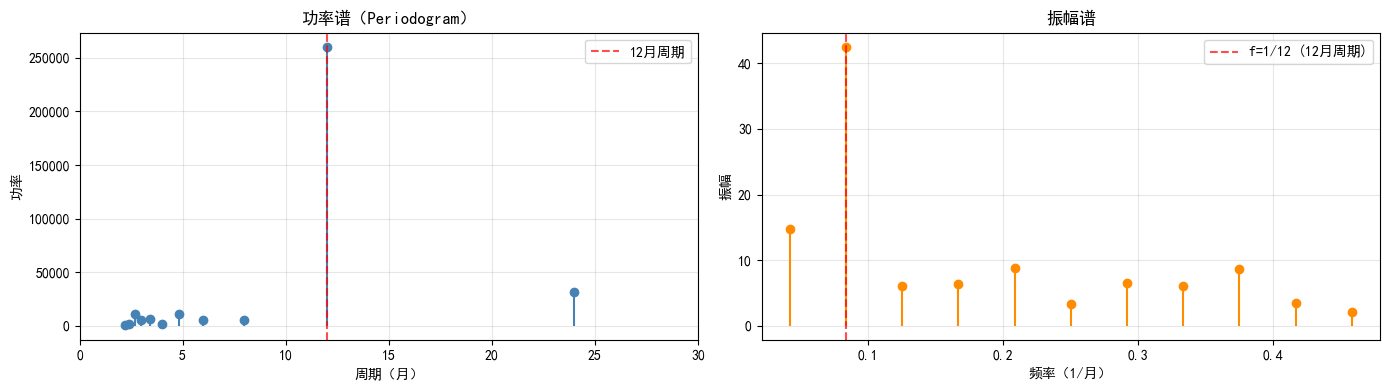

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 功率谱（周期为横轴）
axes[0].stem(periods, power, basefmt=' ', linefmt='steelblue', markerfmt='o')
axes[0].set_xlim(0, 30)
axes[0].set_xlabel('周期（月）')
axes[0].set_ylabel('功率')
axes[0].set_title('功率谱（Periodogram）')
axes[0].grid(True, alpha=0.3)
# 标注 12 个月周期
axes[0].axvline(x=12, color='red', linestyle='--', alpha=0.7, label='12月周期')
axes[0].legend()

# 振幅谱（频率为横轴）
axes[1].stem(freqs_pos, amplitude, basefmt=' ', linefmt='darkorange', markerfmt='o')
axes[1].set_xlabel('频率（1/月）')
axes[1].set_ylabel('振幅')
axes[1].set_title('振幅谱')
axes[1].grid(True, alpha=0.3)
# 标注 12月周期对应的频率
axes[1].axvline(x=1/12, color='red', linestyle='--', alpha=0.7, label='f=1/12 (12月周期)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 频率滤波：分解趋势 + 季节性 + 残差

利用 FFT 分解的逆向思路——**把特定频率的成分保留，其余置零，再逆变换回时域**：

| 成分 | 频率范围 | 含义 |
|------|---------|------|
| **趋势** | 最低频（周期 > 18 个月） | 长期上升/下降方向 |
| **季节性** | 中频（周期 ~12 个月） | 每年的规律波动 |
| **残差** | 其余 | 不规则噪声 |

这种方法的优点：**不需要预先假设趋势是线性的**，可以拟合任意形状的趋势。

In [6]:
# 设定频率阈值
n = len(y)
fft_vals = fft(y)

# --- 趋势成分：保留周期 > 18 个月的低频 ---
trend_fft = fft_vals.copy()
trend_cutoff = 1 / 18  # 周期 18 个月对应的频率
trend_fft[np.abs(freqs) > trend_cutoff] = 0
trend_component = np.real(ifft(trend_fft))

# --- 季节性成分：保留 12 个月周期附近 ---
seasonal_fft = fft_vals.copy()
# 保留 10~14 个月周期范围
seasonal_low = 1 / 14
seasonal_high = 1 / 10
mask = (np.abs(freqs) < seasonal_low) | (np.abs(freqs) > seasonal_high)
seasonal_fft[mask] = 0
seasonal_component = np.real(ifft(seasonal_fft))

# --- 残差：原始值 - 趋势 - 季节 ---
residual_component = y - trend_component - seasonal_component

# 结果汇总
decomp = pd.DataFrame({
    '原始值': y,
    '趋势': trend_component,
    '季节性': seasonal_component,
    '残差': residual_component
}, index=df.index)
print('FFT 分解结果（前 6 个月）：')
display(decomp.head(6).round(1))

FFT 分解结果（前 6 个月）：


,原始值,趋势,季节性,残差
date,,,,
2024-06-01,132.8,195.7,-42.0,-20.9
2024-07-01,140.9,191.8,-33.0,-18.0
2024-08-01,175.7,188.0,-15.1,2.8
2024-09-01,211.8,184.5,6.8,20.5
2024-10-01,203.1,181.5,26.9,-5.3
2024-11-01,211.5,179.2,39.7,-7.5


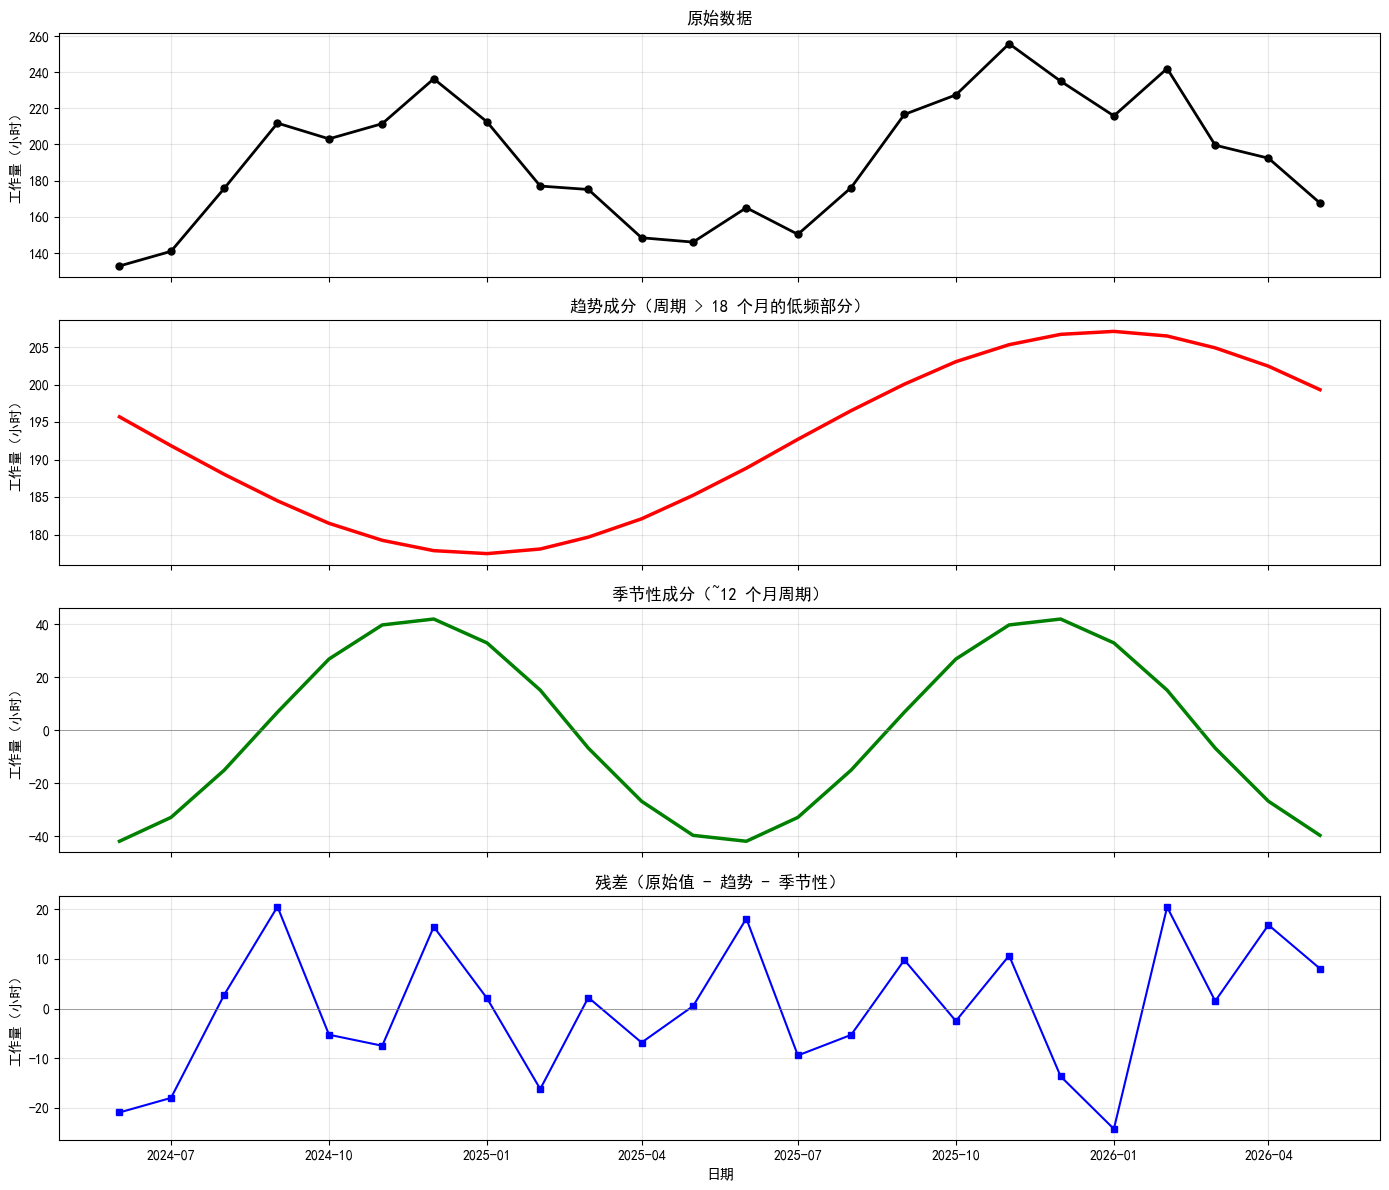

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(decomp.index, decomp['原始值'], 'ko-', linewidth=2, markersize=5)
axes[0].set_title('原始数据')
axes[0].set_ylabel('工作量（小时）')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp.index, decomp['趋势'], 'r-', linewidth=2.5)
axes[1].set_title('趋势成分（周期 > 18 个月的低频部分）')
axes[1].set_ylabel('工作量（小时）')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp.index, decomp['季节性'], 'g-', linewidth=2.5)
axes[2].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[2].set_title('季节性成分（~12 个月周期）')
axes[2].set_ylabel('工作量（小时）')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp.index, decomp['残差'], 'b-', linewidth=1.5, marker='s', markersize=4)
axes[3].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[3].set_title('残差（原始值 - 趋势 - 季节性）')
axes[3].set_ylabel('工作量（小时）')
axes[3].set_xlabel('日期')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 分解结果的业务解读

从分解结果可以观察到：
1. **趋势**：工作量整体呈上升趋势（从约 160h → 约 210h），说明业务在增长
2. **季节性**：每年年底到次年年初（11月~2月）是高峰期，年中（6月~7月）是低谷期
3. **残差**：基本围绕 0 波动，幅度约 ±20h，说明分解效果良好（没有明显的遗漏模式）

> 这个小结是手工解读，实际项目中可以进一步用残差的标准差来量化噪声水平。

---
## 4. 数据划分

将最后 2 个月（2026-04、2026-05）作为 **验证集**，之前 22 个月作为 **训练集**。

这样模拟「用过去预测未来」的真实场景。

> 验证集用 2 个月而非 6 个月，是因为：
> - 如果预留 6 个月做验证，训练集只剩 18 个月，不足以让季节性模型充分学习
> - 我们选择信任较近期的验证结果来挑选模型，然后用全部 24 个月数据预测未来 6 个月

In [8]:
n_validation = 2  # 验证集月数
n_forecast = 6    # 预测步长

train = df.iloc[:-n_validation].copy()
test = df.iloc[-n_validation:].copy()

print(f'训练集：{train.index[0].date()} ~ {train.index[-1].date()}（{len(train)} 个月）')
print(f'验证集：{test.index[0].date()} ~ {test.index[-1].date()}（{len(test)} 个月）')
print(f'目标预测：未来 {n_forecast} 个月')

训练集：2024-06-01 ~ 2026-03-01（22 个月）
验证集：2026-04-01 ~ 2026-05-01（2 个月）
目标预测：未来 6 个月


---
## 5. 预测方法

### 5.1 Naive 季节法（基线）

**原理**：直接用去年同期的值作为今年的预测值。

In [9]:
def naive_seasonal(train, test):
    pred = []
    for date in test.index:
        last_year = date - pd.DateOffset(years=1)
        if last_year in train.index:
            pred.append(train.loc[last_year, 'workload'])
        else:
            pred.append(np.nan)
    return pd.Series(pred, index=test.index)

y_pred_naive = naive_seasonal(train, test)
print('Naive 季节法预测值：')
print(y_pred_naive.round(1))

Naive 季节法预测值：
date
2026-04-01    148.4
2026-05-01    146.0
Freq: MS, dtype: float64


### 5.2 简单移动平均（SMA）

**原理**：取最近 N 个月的均值作为下个月的预测值。

$$\hat{y}_{t+1} = \frac{1}{N} \sum_{i=0}^{N-1} y_{t-i}$$

注意：这里用一个"滚动"过程——每预测一个月，就把该月真实值加入历史再预测下一个月。
这模拟了"每次只预测下一个月"的场景，和一次性预测 6 个月不同。

In [10]:
def moving_average(train, test, window=3):
    history = list(train['workload'])
    pred = []
    for _ in range(len(test)):
        forecast = np.mean(history[-window:])
        pred.append(forecast)
        history.append(test['workload'].iloc[len(pred)-1])
    return pd.Series(pred, index=test.index)

y_pred_sma3 = moving_average(train, test, window=3)
y_pred_sma6 = moving_average(train, test, window=6)
print('SMA(3) 预测：', y_pred_sma3.values.round(1))
print('SMA(6) 预测：', y_pred_sma6.values.round(1))

SMA(3) 预测： [219.1 211.3]
SMA(6) 预测： [229.2 223.4]


### 5.3 Holt's Linear Trend（指数平滑）

**原理**：对水平、趋势两个成分做指数加权平滑。

两个参数：
- `alpha`：水平平滑系数
- `beta`：趋势平滑系数

> 注：完整 Holt-Winters 还包含季节性成分，但需要至少 2 个完整季节周期（24 个月）
> 的数据来初始化。我们的训练集只有 22 个月，因此这里使用无季节的 Holt 版本。

优点：能捕捉趋势，计算快。
缺点：无法处理季节性。

In [11]:
hw_model = ExponentialSmoothing(
    train['workload'],
    trend='add',
    seasonal=None,
).fit()

y_pred_hw = hw_model.forecast(len(test))
print('Holt 指数平滑预测值：', y_pred_hw.values.round(1))

Holt 指数平滑预测值： [202.8 206. ]


### 5.4 SARIMA 模型

**原理**：ARIMA（差分自回归移动平均）的扩展版，增加了季节性成分。

SARIMA(p,d,q)(P,D,Q,S) 的参数含义：
- `p`：自回归阶数（用过去几个值预测当前值）
- `d`：差分阶数（让数据平稳）
- `q`：移动平均阶数（用过去几个误差修正预测）
- `S`：季节周期长度（这里 S=12 个月）

使用 `auto_arima` 自动搜索最优参数组合。

In [12]:
print('正在自动搜索最优 SARIMA 参数（可能需要几秒钟）...')
auto_model = auto_arima(
    train['workload'],
    seasonal=True,
    m=12,
    trace=False,
    suppress_warnings=True,
    stepwise=True,
    max_order=6,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1
)
print(f'最优 SARIMA 参数：{auto_model.order} x {auto_model.seasonal_order}')

from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train['workload'],
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

y_pred_sarima = sarima_model.forecast(len(test))
print('SARIMA 预测值：', y_pred_sarima.values.round(1))

正在自动搜索最优 SARIMA 参数（可能需要几秒钟）...


最优 SARIMA 参数：(1, 0, 2) x (0, 1, 0, 12)
SARIMA 预测值： [125.2 141.8]


### 5.5 线性回归（特征工程）

**原理**：把时间序列转换成监督学习问题，构造特征：
- `t`：时间序号（捕捉趋势）
- `month`：月份虚拟变量（捕捉季节）

优点：可解释性强，训练快。
缺点：假设线性关系，无法捕捉复杂模式。

In [13]:
def prepare_lr_data(data):
    X = pd.DataFrame({
        't': np.arange(len(data)),
        'month': data.index.month
    })
    X = pd.get_dummies(X, columns=['month'], prefix='m')
    for m in range(1, 13):
        col = f'm_{m}'
        if col not in X.columns:
            X[col] = 0
    return X.sort_index(axis=1)

X_train = prepare_lr_data(train)
y_train = train['workload']

lr = LinearRegression()
lr.fit(X_train, y_train)

X_test = prepare_lr_data(test)
X_test['t'] = np.arange(len(train), len(train) + len(test))
y_pred_lr = lr.predict(X_test[X_train.columns])

print(f'线性回归 R^2 = {lr.score(X_train, y_train):.3f}')
print('线性回归预测值：', y_pred_lr.round(1))

线性回归 R^2 = 0.923
线性回归预测值： [169.1 166.7]


---
## 6. 误差对比 & 模型选择

三种误差指标：
- **MAE**（平均绝对误差）：直观易懂
- **RMSE**（均方根误差）：对大误差惩罚更大
- **MAPE**（平均绝对百分比误差）：无量纲，适合跨场景对比

In [14]:
def evaluate(y_true, y_pred, name):
    y_true = y_true.values
    y_pred = y_pred.values if hasattr(y_pred, 'values') else np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'方法': name, 'MAE': round(mae, 1), 'RMSE': round(rmse, 1), 'MAPE(%)': round(mape, 2)}

results = []
results.append(evaluate(test, y_pred_naive, 'Naive 季节法'))
results.append(evaluate(test, y_pred_sma3, 'SMA(3)'))
results.append(evaluate(test, y_pred_sma6, 'SMA(6)'))
results.append(evaluate(test, y_pred_hw, 'Holt 指数平滑'))
results.append(evaluate(test, y_pred_sarima, 'SARIMA'))
results.append(evaluate(test, y_pred_lr, '线性回归'))

eval_df = pd.DataFrame(results).set_index('方法')
print('误差对比：')
display(eval_df)

best_method = eval_df['RMSE'].idxmin()
print(f'最优方法（基于 RMSE）：{best_method}')

误差对比：


,MAE,RMSE,MAPE(%)
方法,,,
Naive 季节法,32.8,34.7,17.83
SMA(3),35.2,36.2,20.14
SMA(6),46.3,47.3,26.34
Holt 指数平滑,24.4,28.1,14.08
SARIMA,46.5,50.9,25.48
线性回归,12.1,16.5,6.73


最优方法（基于 RMSE）：线性回归


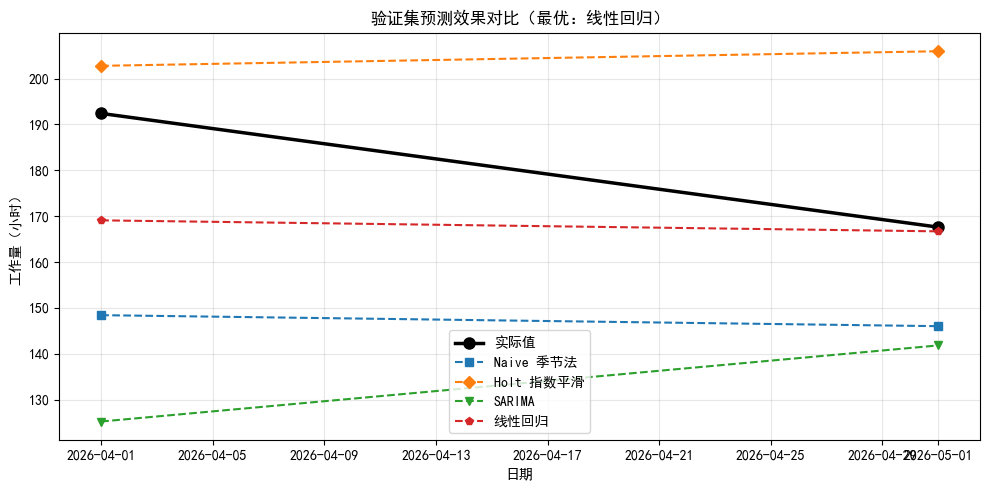

In [15]:
# 验证集可视化对比
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(test.index, test['workload'], 'ko-', linewidth=2.5, markersize=8, label='实际值')
ax.plot(test.index, y_pred_naive, 's--', label='Naive 季节法')
ax.plot(test.index, y_pred_hw, 'D--', label='Holt 指数平滑')
ax.plot(test.index, y_pred_sarima, 'v--', label='SARIMA')
ax.plot(test.index, y_pred_lr, 'p--', label='线性回归')

ax.set_title(f'验证集预测效果对比（最优：{best_method}）')
ax.set_xlabel('日期')
ax.set_ylabel('工作量（小时）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. 预测未来 6 个月

用最优模型 + 全部 24 个月的数据来预测 2026-06 ~ 2026-11。

> **为什么用全部数据？** 数据越多，模型对趋势和季节性的估计越稳定。
> 由于全量数据有 24 个月（2 个完整季节周期），Holt-Winters 的季节版本也可以使用了。

> **关于预测可靠性**：预测跨度越长，不确定性越大。
> - 第 1~2 个月：相对可靠（延续近期趋势）
> - 第 3~6 个月：不确定性增加（趋势可能变化、季节性模式可能偏移）
> - 建议关注整体方向而非精确数值，并随新数据滚动更新预测

In [16]:
future_dates = pd.date_range(start='2026-06-01', periods=n_forecast, freq='MS')
print(f'预测目标：{future_dates[0].date()} ~ {future_dates[-1].date()}（共 {len(future_dates)} 个月）')

future_pred = {}

# --- Naive 季节法 ---
def naive_seasonal_forecast(data, future_dates):
    pred = []
    for date in future_dates:
        last_year = date - pd.DateOffset(years=1)
        if last_year in data.index:
            pred.append(data.loc[last_year, 'workload'])
        else:
            pred.append(np.nan)
    return np.array(pred)
future_pred['Naive 季节法'] = naive_seasonal_forecast(df, future_dates)

# --- Holt-Winters（全量数据 24 个月，启用季节性）---
hw_full = ExponentialSmoothing(
    df['workload'], trend='add', seasonal='add', seasonal_periods=12
).fit()
future_pred['Holt-Winters（季节）'] = hw_full.forecast(n_forecast).values

# --- SARIMA ---
sarima_full = SARIMAX(
    df['workload'],
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
future_pred['SARIMA'] = sarima_full.forecast(n_forecast).values

# --- 线性回归 ---
X_full = prepare_lr_data(df)
lr_full = LinearRegression().fit(X_full, df['workload'])
X_future = prepare_lr_data(
    pd.DataFrame({'workload': [0] * n_forecast}, index=future_dates)
)
X_future['t'] = np.arange(len(df), len(df) + n_forecast)
future_pred['线性回归'] = lr_full.predict(X_future[X_full.columns]).round(1)

# 整理结果
future_df = pd.DataFrame(future_pred, index=[d.date() for d in future_dates])
future_df.index.name = '日期'
print('\n未来 6 个月预测结果（各方法对比）：')
display(future_df.round(1))

预测目标：2026-06-01 ~ 2026-11-01（共 6 个月）



未来 6 个月预测结果（各方法对比）：


D:\DevZone\Projects\AgentProjects\TimeSeriesPrediction\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Naive 季节法,Holt-Winters（季节）,SARIMA,线性回归
日期,,,,
2026-06-01,165.0,183.0,223.8,183.0
2026-07-01,150.3,179.7,205.9,179.7
2026-08-01,176.1,209.9,239.6,210.0
2026-09-01,216.6,248.2,289.1,248.3
2026-10-01,227.4,249.3,310.2,249.3
2026-11-01,255.7,267.7,350.2,267.7


### 7.1 推荐结果

基于验证集表现最好的模型给出推荐。

同时计算所有模型的均值作为 **集成预测** —— 多个模型组合往往比单一模型更稳定。

In [17]:
recommended = future_pred[best_method]
ensemble = np.mean([v for v in future_pred.values()], axis=0)

print(f'推荐结果（基于 {best_method}）：')
print('-' * 50)
for i, d in enumerate(future_dates):
    print(f'  {d.month}月（{d.date()}）  {recommended[i]:>6.1f} 小时')

print(f'\n集成预测（各方法均值）：')
print('-' * 50)
for i, d in enumerate(future_dates):
    print(f'  {d.month}月（{d.date()}）  {ensemble[i]:>6.1f} 小时')

# 误差范围提示
print(f'\n重要提示：预测越远，误差越大')
print(f'   第1-2个月：参考误差约 +/- {eval_df.loc[best_method, "MAE"]:.0f} 小时（验证集 MAE）')
print(f'   第3-6个月：实际误差可能显著大于验证集 MAE，建议谨慎参考')

推荐结果（基于 线性回归）：
--------------------------------------------------
  6月（2026-06-01）   183.0 小时
  7月（2026-07-01）   179.7 小时
  8月（2026-08-01）   210.0 小时
  9月（2026-09-01）   248.3 小时
  10月（2026-10-01）   249.3 小时
  11月（2026-11-01）   267.7 小时

集成预测（各方法均值）：
--------------------------------------------------
  6月（2026-06-01）   188.7 小时
  7月（2026-07-01）   178.9 小时
  8月（2026-08-01）   208.9 小时
  9月（2026-09-01）   250.6 小时
  10月（2026-10-01）   259.0 小时
  11月（2026-11-01）   285.3 小时

重要提示：预测越远，误差越大
   第1-2个月：参考误差约 +/- 12 小时（验证集 MAE）
   第3-6个月：实际误差可能显著大于验证集 MAE，建议谨慎参考


---
## 8. 汇总可视化

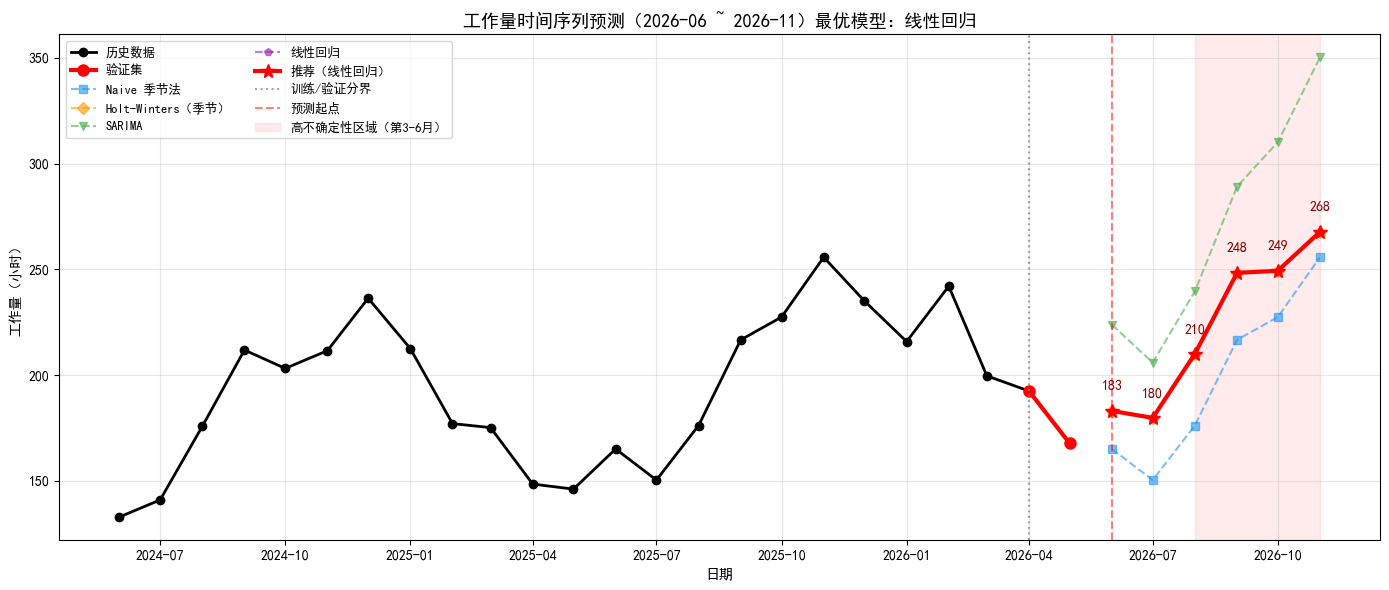

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

# 历史数据
ax.plot(df.index, df['workload'], 'ko-', linewidth=2, markersize=6, label='历史数据')

# 验证集
ax.plot(test.index, test['workload'], 'ro-', linewidth=3, markersize=8, label='验证集')

# 各模型预测
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
styles = ['s--', 'D--', 'v--', 'p--']
for i, (name, pred) in enumerate(future_pred.items()):
    ax.plot(future_dates, pred, styles[i], color=colors[i],
            linewidth=1.5, markersize=6, alpha=0.6, label=name)

# 推荐预测（高亮）
ax.plot(future_dates, recommended, 'r*-', linewidth=3, markersize=10,
        label=f'推荐（{best_method}）', zorder=5)

# 标注
for i, (d, v) in enumerate(zip(future_dates, recommended)):
    ax.annotate(f'{v:.0f}', (d, v), textcoords='offset points',
                xytext=(0, 15), ha='center', fontsize=10, fontweight='bold', color='darkred')

# 分界线
ax.axvline(x=test.index[0], color='gray', linestyle=':', alpha=0.7, label='训练/验证分界')
ax.axvline(x=future_dates[0], color='red', linestyle='--', alpha=0.5, label='预测起点')

# 不确定性提示区域
ax.axvspan(future_dates[2], future_dates[-1], alpha=0.08, color='red',
           label='高不确定性区域（第3-6月）')

ax.set_title(f'工作量时间序列预测（2026-06 ~ 2026-11）最优模型：{best_method}', fontsize=13)
ax.set_xlabel('日期')
ax.set_ylabel('工作量（小时）')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. 总结

### 预测 6 个月 vs 预测 2 个月，有哪些不同？

| 维度 | 预测 2 个月 | 预测 6 个月 |
|------|-----------|-----------|
| 误差累积 | 少 | 多（误差随步长放大） |
| 模型适用性 | 几乎所有模型都可用 | 需要稳健的趋势/季节建模 |
| 季节性作用 | 短期趋势主导 | 季节性模式更重要 |
| 结果可靠性 | 较高 | 仅供参考方向 |

### 提升 6 个月预测精度的方法

1. **滚动更新**：每个月出真实值后，重新训练模型再预测剩余月份
2. **更多历史数据**：3~5 年的月度数据能让 SARIMA 和 Holt-Winters 的季节成分学习得更好
3. **集成预测**：多个模型的加权平均比单一模型更稳定（上面已实现）
4. **加入外部特征**：比如业务计划、市场指标等，辅助模型捕捉趋势变化
5. **不确定性量化**：使用预测区间（prediction interval）而不是单点预测